# Image-Space Lane Assignment — fixed camera, YOLO vehicle detection

**What this is.** The real-world version of the lane-assignment idea, no map and no homography.
The camera is *fixed*, so the lane geometry is constant: you **draw the lane polygons once** on a
camera image (calibration), then every frame is:

```
YOLO detect vehicles ─▶ foot point (bottom-centre of box) ─▶ point-in-polygon ─▶ lane ─▶ count
```

- **Lanes** are drawn by hand *once* (a fixed camera only needs calibrating once). That's the only
  manual step.
- **Vehicles** are found automatically by **YOLO11** (newer than YOLOv8). The foot point — where the
  car meets the road — is derived from each detection box (`((x1+x2)/2, y2)`), no clicking.

**Test subject:** `data/test1.png` (a fixed CARLA camera frame). Swap `IMG_PATH` for your own
fixed-camera image and the rest is identical.

> **Clicking the lanes inside Jupyter** needs the interactive `widget` backend (`ipympl`), set in the
> next cell. The default `inline` backend renders a *static* image and can't capture clicks. If
> `%matplotlib widget` errors, `pip install ipympl` into this kernel and restart it.
> **YOLO** needs `ultralytics` + `torch` in this kernel (`pip install ultralytics`).

Loaded ../data/test1.png: 1600x899


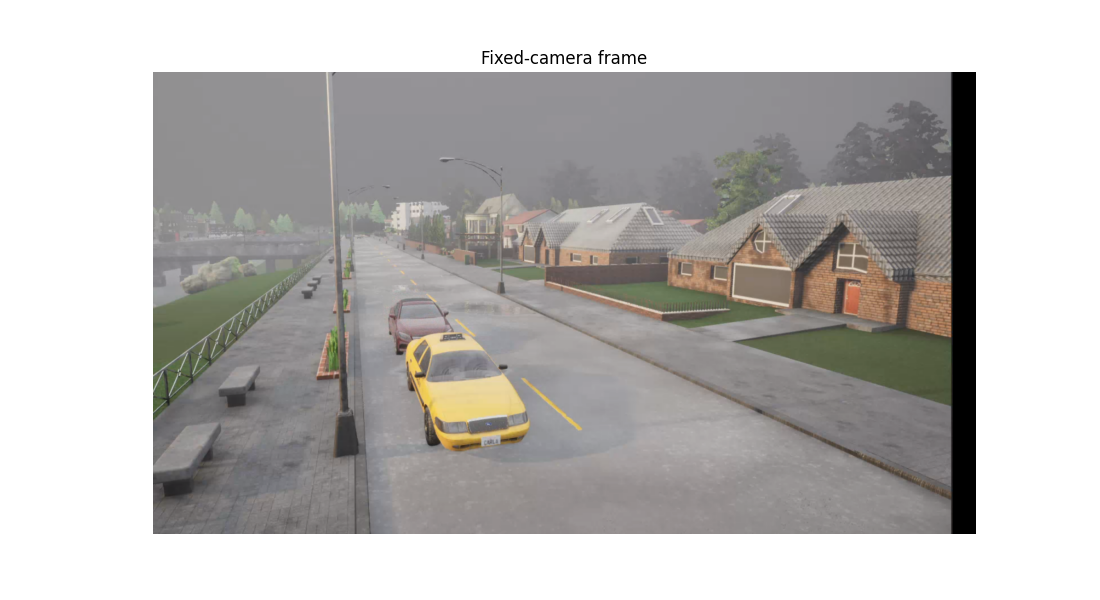

In [2]:
%matplotlib widget
import os, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from collections import Counter
from PIL import Image

# ── config ──────────────────────────────────────────────────────────────────
IMG_PATH   = "../data/test1.png"          # fixed-camera frame to calibrate / test on
CALIB_PATH = "../data/lane_calibration.json"   # drawn polygons are saved here (calibrate once)
YOLO_MODEL = "../models/yolo11n.pt"              # nano; swap for yolo11s/m or yolo12* for more accuracy
CONF       = 0.25                      # detection confidence threshold

img = np.asarray(Image.open(IMG_PATH).convert("RGB"))
H, W = img.shape[:2]
print(f"Loaded {IMG_PATH}: {W}x{H}")

fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(img); ax.set_title("Fixed-camera frame"); ax.axis("off")
plt.show()

## Step 1 — Calibrate the lanes (draw polygons once)

Run the picker cell, then click on the image:

| action | what it does |
|---|---|
| **left-click** | add a corner to the current lane |
| key **`n`** | finish this lane (needs ≥3 corners), start the next |
| key **`u`** | undo the last corner |
| key **`f`** | finish calibration |

Then run the **save** cell. The polygons go to `lane_calibration.json`, so later sessions just load
them — you only calibrate once per fixed camera.

In [3]:
def save_calibration(lanes, path=CALIB_PATH):
    if not lanes:
        print("Nothing to save — draw at least one lane first."); return
    with open(path, "w") as f:
        json.dump({"image": IMG_PATH, "size": [W, H], "lanes": lanes}, f, indent=2)
    print(f"Saved {len(lanes)} lanes -> {path}")

def load_calibration(path=CALIB_PATH):
    if not os.path.exists(path):
        return {}
    with open(path) as f:
        return json.load(f).get("lanes", {})


class PolygonPicker:
    """Click lane polygons on the image (widget backend). left-click=corner,
    n=next lane, u=undo, f=finish. Result in `.lanes` -> {name: [(x,y), ...]}."""
    def __init__(self, image):
        self.image, self.lanes, self.current, self.idx = image, {}, [], 0
        self.fig, self.ax = plt.subplots(figsize=(11, 6))
        self.fig.canvas.mpl_connect("button_press_event", self._on_click)
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)
        self._redraw()

    def _title(self):
        return (f"lane_{self.idx}  |  left-click=corner   n=next   u=undo   f=finish"
                f"   ({len(self.lanes)} saved)")

    def _on_click(self, e):
        if e.inaxes == self.ax and e.xdata is not None:
            self.current.append((float(e.xdata), float(e.ydata)))
            self._redraw()

    def _commit(self):
        if len(self.current) >= 3:
            self.lanes[f"lane_{self.idx}"] = self.current
            self.idx += 1; self.current = []
            return True
        return False

    def _on_key(self, e):
        if e.key == "u" and self.current:
            self.current.pop()
        elif e.key == "n":
            self._commit()
        elif e.key == "f":
            self._commit()
            self.ax.set_title(f"DONE — {len(self.lanes)} lanes. Run the save cell.")
            self.fig.canvas.draw_idle(); return
        self._redraw()

    def _redraw(self):
        self.ax.clear(); self.ax.imshow(self.image); self.ax.axis("off")
        self.ax.set_title(self._title())
        for name, poly in self.lanes.items():
            p = np.array(poly + [poly[0]])
            self.ax.plot(p[:, 0], p[:, 1], "-o", lw=2)
            c = np.mean(poly, axis=0)
            self.ax.text(c[0], c[1], name, color="yellow", fontsize=12, ha="center")
        if self.current:
            p = np.array(self.current)
            self.ax.plot(p[:, 0], p[:, 1], "-o", lw=2, color="red")
        self.fig.canvas.draw_idle()

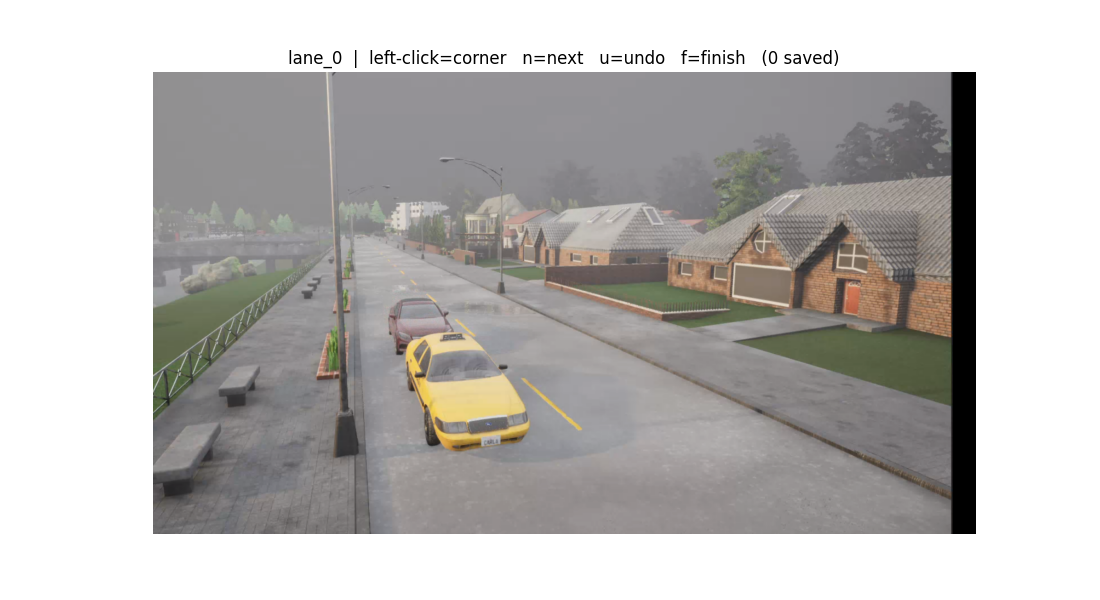

In [4]:
# ── INTERACTIVE: draw the lanes ──  (left-click corners, n=next, u=undo, f=finish)
picker = PolygonPicker(img)

In [5]:
# ── run AFTER drawing to save the calibration ──
save_calibration(picker.lanes)

Saved 2 lanes -> ../data/lane_calibration.json


### Resolve the calibration

Loads `lane_calibration.json` if it exists (what you just drew), otherwise falls back to rough
`SEED_LANES` for `test1.png` so the notebook still runs before you've calibrated, then shows the
polygons overlaid.

Using 2 lanes from ../data/lane_calibration.json


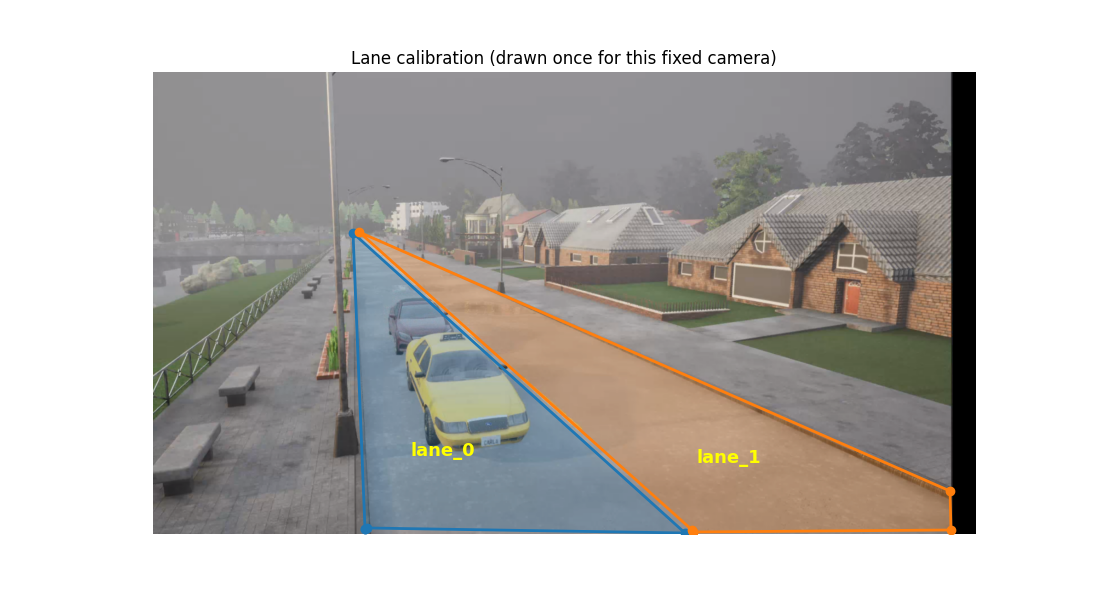

In [6]:
SEED_LANES = {
    "lane_L": [(300, 899), (565, 899), (640, 360), (560, 360)],   # near / driver-side lane
    "lane_R": [(565, 899), (880, 899), (705, 360), (640, 360)],   # adjacent lane
}

LANES = load_calibration() or SEED_LANES
src = CALIB_PATH if load_calibration() else "SEED_LANES (rough — calibrate to refine)"
print(f"Using {len(LANES)} lanes from {src}")

fig, ax = plt.subplots(figsize=(11, 6)); ax.imshow(img); ax.axis("off")
for name, poly in LANES.items():
    p = np.array(poly + [poly[0]])
    ax.fill(p[:, 0], p[:, 1], alpha=0.25)
    ax.plot(p[:, 0], p[:, 1], "-o", lw=2)
    c = np.mean(poly, axis=0)
    ax.text(c[0], c[1], name, color="yellow", fontsize=13, ha="center", weight="bold")
ax.set_title("Lane calibration (drawn once for this fixed camera)"); plt.show()

## Step 2 — Detect vehicles with YOLO

Load YOLO11 once and run it on the frame. We keep only **vehicle** classes and, for each detection,
compute the **foot point** = bottom-centre of the box `((x1+x2)/2, y2)` — the pixel where the car
meets the road, which is what we test against the ground-plane lane polygons. No manual clicking.

In [ ]:
from ultralytics import YOLO

# COCO vehicle classes: bicycle, car, motorcycle, bus, truck
VEHICLE_CLASSES = {1, 2, 3, 5, 7}

_model = YOLO(YOLO_MODEL)   # downloads weights on first use; cached afterwards

def detect_vehicles(image, model=_model, conf=CONF):
    """Return list of detections: {box:(x1,y1,x2,y2), foot:(x,y), cls:str, conf:float}."""
    res = model(image, conf=conf, verbose=False)[0]
    dets = []
    for b in res.boxes:
        cls = int(b.cls)
        if cls not in VEHICLE_CLASSES:
            continue
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        dets.append({
            "box":  (x1, y1, x2, y2),
            "foot": ((x1 + x2) / 2.0, y2),
            "cls":  res.names[cls],
            "conf": float(b.conf),
        })
    return dets

detections = detect_vehicles(img)
print(f"Detected {len(detections)} vehicles with {YOLO_MODEL}:")
for d in detections:
    print(f"  {d['cls']:10} conf={d['conf']:.2f}  foot=({d['foot'][0]:.0f}, {d['foot'][1]:.0f})")

ModuleNotFoundError: No module named 'torch'

## Step 3 — Assign each vehicle to a lane (point-in-polygon)

Pure image-space test: is the detection's foot point inside a lane polygon? A car whose foot point is
in no polygon is correctly **unassigned** (parked off-road, on a footpath…), not a miss.

In [ ]:
lane_paths = {name: MplPath(np.array(poly)) for name, poly in LANES.items()}

def assign(foot_xy):
    for name, path in lane_paths.items():
        if path.contains_point(foot_xy):
            return name
    return None

for d in detections:
    d["lane"] = assign(d["foot"])
    print(f"  {d['cls']:10} foot=({d['foot'][0]:.0f}, {d['foot'][1]:.0f})  ->  {d['lane'] or '— (no lane)'}")

# ── visualise: YOLO boxes + foot points coloured by assigned lane + lane polygons ──
cmap = {name: plt.cm.tab10(i) for i, name in enumerate(LANES)}
fig, ax = plt.subplots(figsize=(11, 6)); ax.imshow(img); ax.axis("off")
for name, poly in LANES.items():
    p = np.array(poly + [poly[0]])
    ax.fill(p[:, 0], p[:, 1], alpha=0.18, color=cmap[name])
    ax.plot(p[:, 0], p[:, 1], "-", lw=2, color=cmap[name])
    c = np.mean(poly, axis=0)
    ax.text(c[0], c[1], name, color="white", fontsize=12, ha="center", weight="bold")
for d in detections:
    x1, y1, x2, y2 = d["box"]
    col = cmap[d["lane"]] if d["lane"] else (1, 1, 1, 1)
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=col, lw=2))
    ax.scatter(*d["foot"], s=110, marker="o", edgecolors="k", linewidths=1.5, color=col, zorder=5)
ax.set_title("YOLO detections + foot points, coloured by assigned lane"); plt.show()

## Step 4 — Per-lane counts → signal demand

Count per lane, then roll lanes up into the **signal phases** they belong to (set once with the
polygons, since the camera is fixed). The phase demands feed the timing logic.

In [ ]:
counts = Counter(d["lane"] for d in detections if d["lane"])
print("per-lane counts:")
for name in LANES:
    print(f"  {name}: {counts.get(name, 0)}")

# Group lanes into signal phases (calibrate once). Both example lanes = one approach here.
LANE_TO_PHASE = {name: "approach_A" for name in LANES}

phase_demand = Counter()
for name, n in counts.items():
    phase_demand[LANE_TO_PHASE[name]] += n

print("\nphase demand (-> signal timing input):")
for phase, n in phase_demand.items():
    print(f"  {phase}: {n}")